In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os

DATA_PATH  = "finaldata1.csv"
OUT_DIR    = "/Users/varshithareddy/Desktop"

BATCH_SIZE = 16
EPOCHS     = 2000
LR         = 1e-3
PATIENCE   = 40
SEED       = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

INPUT_COLS  = ["lambda1", "a", "r", "n", "alpha"]
OUTPUT_COLS = ["c_fit", "mu_fit"]

df = pd.read_csv(DATA_PATH)

print(f"Loaded dataset: {df.shape}")
print(f"Input  features: {INPUT_COLS}")
print(f"Output targets : {OUTPUT_COLS}")

X = df[INPUT_COLS].values.astype(np.float32)
y = df[OUTPUT_COLS].values.astype(np.float32)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED
)

print(f"\nTrain : {X_train.shape[0]} rows")
print(f"Val   : {X_val.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")


Loaded dataset: (10000, 14)
Input  features: ['lambda1', 'a', 'r', 'n', 'alpha']
Output targets : ['c_fit', 'mu_fit']

Train : 7000 rows
Val   : 1500 rows
Test  : 1500 rows


In [2]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_val_s   = scaler_X.transform(X_val)
X_test_s  = scaler_X.transform(X_test)

y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

In [3]:
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

train_ds = TensorDataset(to_tensor(X_train_s), to_tensor(y_train_s))
val_ds   = TensorDataset(to_tensor(X_val_s),   to_tensor(y_val_s))
test_ds  = TensorDataset(to_tensor(X_test_s),  to_tensor(y_test_s))

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_dl  = DataLoader(test_ds, batch_size=BATCH_SIZE)

In [5]:
class ZPredictor(nn.Module):

    def __init__(self, in_dim=5, out_dim=2, dropout=0.2):
        super().__init__()

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(),
                nn.Dropout(dropout)
            )

        self.net = nn.Sequential(
            block(in_dim, 64),
            block(64, 128),
            block(128, 128),
            block(128, 64),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

model = ZPredictor(
    in_dim=len(INPUT_COLS),
    out_dim=len(OUTPUT_COLS)
)

In [6]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=30
)

In [7]:
train_losses = []
val_losses   = []
best_val_loss = np.inf
patience_counter = 0
best_model_state = None
print("\nTraining...")
print(f"{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12}")
print("-" * 45)
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(xb)
    train_loss /= len(train_ds)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_dl:
            pred = model(xb)
            val_loss += criterion(pred, yb).item() * len(xb)
    val_loss /= len(val_ds)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)
    if epoch % 20 == 0 or epoch == 1:
        print(f"{epoch:>6} | "
              f"{train_loss:>12.6f} | "
              f"{val_loss:>12.6f}")
    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {
            k: v.clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break
# restore the best model
model.load_state_dict(best_model_state)

print(f"\nBest validation loss: {best_val_loss:.6f}")


Training...
 Epoch |   Train Loss |     Val Loss
---------------------------------------------
     1 |     0.219287 |     0.069952
    20 |     0.096003 |     0.037140
    40 |     0.079654 |     0.031107
    60 |     0.077446 |     0.030444
    80 |     0.067244 |     0.021509

Early stopping at epoch 88

Best validation loss: 0.015968


In [8]:
model.eval()
preds_s_list   = []
targets_s_list = []
with torch.no_grad():
    for xb, yb in test_dl:
        preds_s_list.append(model(xb).numpy())
        targets_s_list.append(yb.numpy())
preds_s   = np.concatenate(preds_s_list)
targets_s = np.concatenate(targets_s_list)
# Inverse transform
preds   = scaler_y.inverse_transform(preds_s)
targets = scaler_y.inverse_transform(targets_s)


In [9]:
print("\n" + "="*60)
print("TEST SET EVALUATION")
print("="*60)
for i, col in enumerate(OUTPUT_COLS):
    mae = np.mean(np.abs(preds[:, i] - targets[:, i]))
    mape = np.mean(
        np.abs((preds[:, i] - targets[:, i]) /
               targets[:, i])
    ) * 100
    ss_res = np.sum((targets[:, i] - preds[:, i])**2)
    ss_tot = np.sum(
        (targets[:, i] - targets[:, i].mean())**2
    )
    r2 = 1 - ss_res / ss_tot
    print(f"\n{col}")
    print(f"MAE  : {mae:.6f}")
    print(f"MAPE : {mape:.2f}%")
    print(f"R²   : {r2:.6f}")
print("="*60)


TEST SET EVALUATION

c_fit
MAE  : 0.005817
MAPE : 3.15%
R²   : 0.983111

mu_fit
MAE  : 0.672184
MAPE : 5.38%
R²   : 0.983643


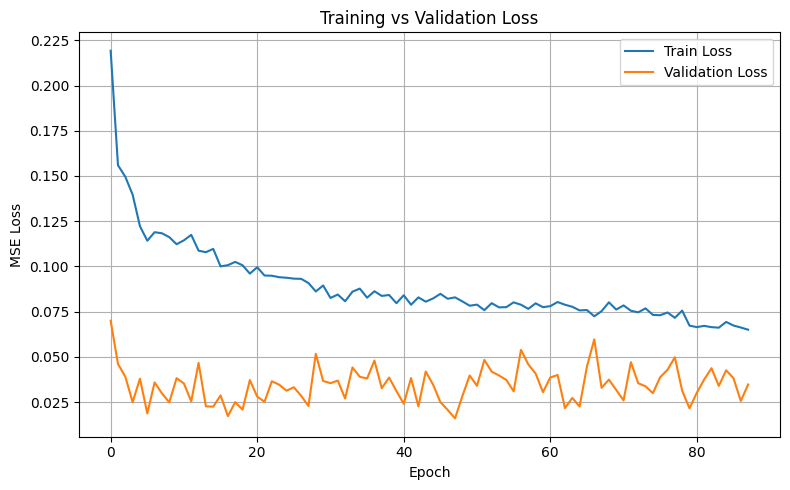

In [10]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

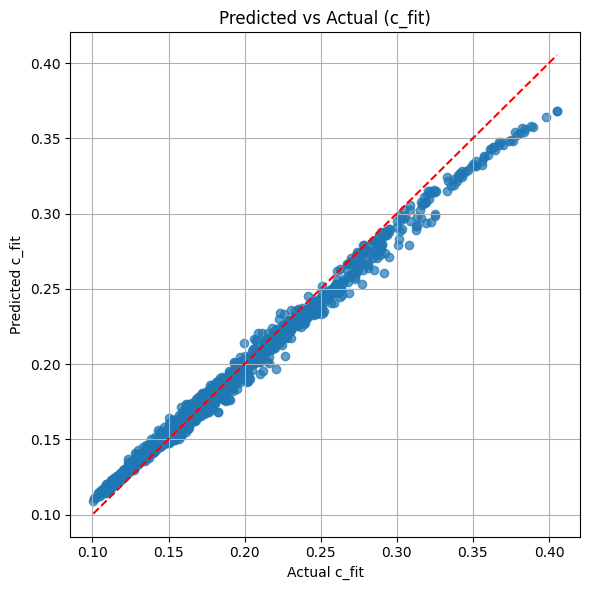

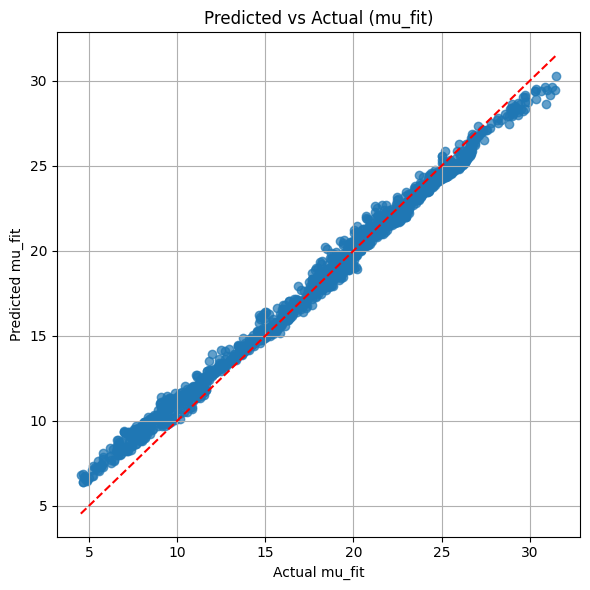

In [11]:
for i, col in enumerate(OUTPUT_COLS):
    plt.figure(figsize=(6,6))
    plt.scatter(
        targets[:, i],
        preds[:, i],
        alpha=0.7
    )
    mn = min(
        targets[:, i].min(),
        preds[:, i].min()
    )
    mx = max(
        targets[:, i].max(),
        preds[:, i].max()
    )
    plt.plot(
        [mn, mx],
        [mn, mx],
        'r--'
    )
    plt.xlabel(f"Actual {col}")
    plt.ylabel(f"Predicted {col}")
    plt.title(f"Predicted vs Actual ({col})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [12]:
save_path = os.path.join(
    OUT_DIR,
    "z_predictor.pt"
)
torch.save({
    'model_state': model.state_dict(),
    'scaler_X_mean': scaler_X.mean_,
    'scaler_X_std': scaler_X.scale_,
    'scaler_y_mean': scaler_y.mean_,
    'scaler_y_std': scaler_y.scale_,
}, save_path)
print(f"\nModel saved to:\n{save_path}")


Model saved to:
/Users/varshithareddy/Desktop/z_predictor.pt


In [13]:
torch.save({
    "model_state": best_model_state,
    "scaler_X_mean": scaler_X.mean_,
    "scaler_X_std":  scaler_X.scale_,
    "scaler_y_mean": scaler_y.mean_,
    "scaler_y_std":  scaler_y.scale_,
    "input_cols":    INPUT_COLS,
    "output_cols":   OUTPUT_COLS,
}, os.path.join(OUT_DIR, "z_predictor.pt"))
print(f"Model saved to {OUT_DIR}/z_predictor.pt")
print("\n── Inference Example ──────────────────────")
print("Input: lambda1=83000, a=1.2e-5, r=0.1143, n=5, alpha=0.2")
 
x_new = np.array([[83000, 1.2e-5, 0.1143, 5, 0.2]], dtype=np.float32)
x_new_s = scaler_X.transform(x_new)
model.eval()
with torch.no_grad():
    pred_s = model(torch.tensor(x_new_s)).numpy()
pred_orig = scaler_y.inverse_transform(pred_s)

Model saved to /Users/varshithareddy/Desktop/z_predictor.pt

── Inference Example ──────────────────────
Input: lambda1=83000, a=1.2e-5, r=0.1143, n=5, alpha=0.2


In [14]:
def predict_cfit_mufit(r_curr):
    x_new   = np.array([[lambda1, a, r_curr, n2, alpha]], dtype=np.float32)
    x_new_s = scaler_X.transform(x_new)
    with torch.no_grad():
        pred_s = model(torch.tensor(x_new_s)).numpy()
    pred   = scaler_y.inverse_transform(pred_s)
    c_fit  = pred[0, 0]
    mu_fit = pred[0, 1]
    return c_fit, mu_fit

In [15]:
n2      = 5
N_total = 30
n1      = N_total - n2
alpha   = 0.2
lambda1 = 83000
a       = 1.2e-5
D       = 60000
N_ITER  = 20
A = (alpha * n1 + 1) / n1
B = (alpha * n2 + 1) / n2
mean_denom = D * (a + 1.0 / lambda1)
# Initial r
s = max(int(alpha * n2), 1)
k = n2 - s
r = 1.0 / ((n2 / (s + 1))**2 + (n2 / (s + 1)))
print(f"\nn1={n1}, n2={n2}, s={s}, k={k}")
print(f"A={A:.6f},  B={B:.6f}")
print(f"mean_denom = D*(a + 1/lambda1) = {mean_denom:.6f}")
print(f"Initial r = {r:.6f}")


n1=25, n2=5, s=1, k=4
A=0.240000,  B=0.400000
mean_denom = D*(a + 1/lambda1) = 1.442892
Initial r = 0.114286


In [16]:
import numpy as np
r_vals     = [r]
beta_vals  = []
cfit_vals  = []
mufit_vals = []
mean_Z2_vals = []
print(f"\n{'Iter':>4}  {'r':>10}  {'c_fit':>10}  {'mu_fit':>10}  "
      f"{'Mean(Z2)':>10}  {'beta':>10}  {'r_new':>10}")
print("-" * 80)
for i in range(N_ITER):
    # Step 1: predict c_fit, mu_fit via NN
    c_fit, mu_fit = predict_cfit_mufit(r)
    # Step 2: Mean(Z2) from fitted exponential
    mean_Z2 = c_fit + 1.0 / mu_fit
    # Step 3: beta from mean matching
    beta = mean_Z2 / mean_denom - r
    # Step 4: r_new from formula
    r_new = B * (A - beta) / (1 + B)
    print(f"{i+1:>4}  {r:>10.6f}  {c_fit:>10.4f}  {mu_fit:>10.4f}  "
          f"{mean_Z2:>10.4f}  {beta:>10.6f}  {r_new:>10.6f}")
    beta_vals.append(beta)
    r_vals.append(r_new)
    cfit_vals.append(c_fit)
    mufit_vals.append(mu_fit)
    mean_Z2_vals.append(mean_Z2)
    # Step 5: update r
    r = r_new
print(f"\nConverged r        = {r_vals[-1]:.6f}")
print(f"Converged beta     = {beta_vals[-1]:.6f}")
print(f"Converged c_fit    = {cfit_vals[-1]:.6f}")
print(f"Converged mu_fit   = {mufit_vals[-1]:.6f}")
print(f"Converged Mean(Z2) = {mean_Z2_vals[-1]:.6f}")
print(f"Converged r1=r+β   = {r_vals[-1] + beta_vals[-1]:.6f}")


Iter           r       c_fit      mu_fit    Mean(Z2)        beta       r_new
--------------------------------------------------------------------------------
   1    0.114286      0.1903     15.6269      0.2543    0.061924    0.050879
   2    0.050879      0.1818     16.8759      0.2410    0.116162    0.035382
   3    0.035382      0.1796     16.8159      0.2390    0.130289    0.031346
   4    0.031346      0.1790     16.7939      0.2385    0.133979    0.030292
   5    0.030292      0.1789     16.7843      0.2385    0.134975    0.030007
   6    0.030007      0.1788     16.7817      0.2384    0.135243    0.029931
   7    0.029931      0.1788     16.7810      0.2384    0.135315    0.029910
   8    0.029910      0.1788     16.7808      0.2384    0.135334    0.029904
   9    0.029904      0.1788     16.7808      0.2384    0.135339    0.029903
  10    0.029903      0.1788     16.7808      0.2384    0.135341    0.029903
  11    0.029903      0.1788     16.7808      0.2384    0.135341    0.0

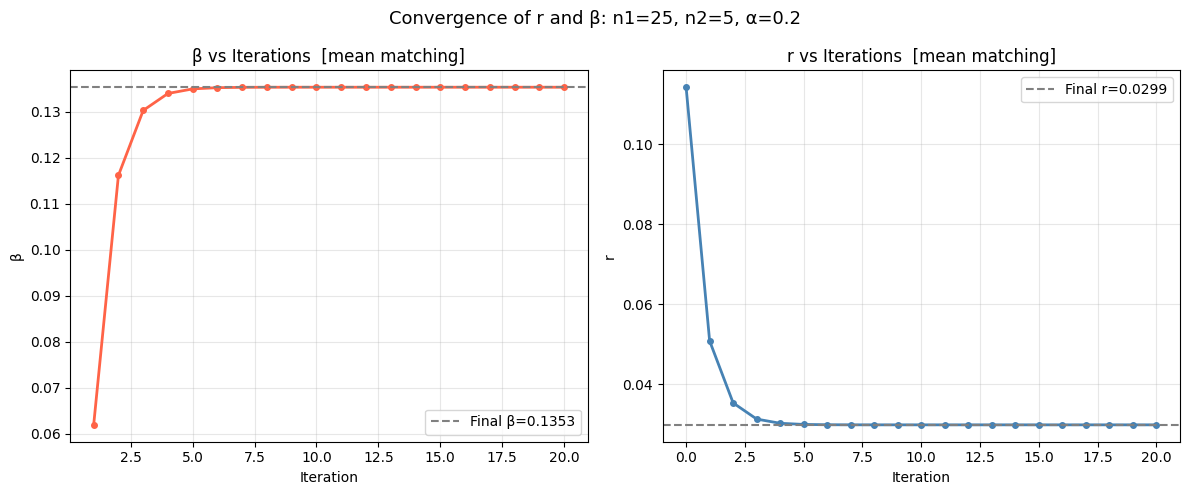

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(range(1, N_ITER+1), beta_vals,
             color='tomato', lw=2, marker='o', markersize=4)
axes[0].axhline(y=beta_vals[-1], color='gray', linestyle='--',
                label=f'Final β={beta_vals[-1]:.4f}')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('β')
axes[0].set_title('β vs Iterations  [mean matching]')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(range(0, N_ITER+1), r_vals,
             color='steelblue', lw=2, marker='o', markersize=4)
axes[1].axhline(y=r_vals[-1], color='gray', linestyle='--',
                label=f'Final r={r_vals[-1]:.4f}')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('r')
axes[1].set_title('r vs Iterations  [mean matching]')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.suptitle(f'Convergence of r and β: '
             f'n1={n1}, n2={n2}, α={alpha}', fontsize=13)
plt.tight_layout()
plt.show()